# Análisis de Residuos — modelo_10_v3
**NovaPay ML · Mayo 2026**

In [15]:
import sys; sys.path.insert(0, ROOT); sys.path.insert(0, os.path.join(ROOT,'scripts'))
X_fe_diag = fe.transform(X_test_raw.copy())
lgb_feats = set(lgb_m.feature_name_)
fe_feats  = set(X_fe_diag.columns)
print("EXTRA en tu FE (no en el modelo):", sorted(fe_feats - lgb_feats))
print("FALTANTES en tu FE (sí en el modelo):", sorted(lgb_feats - fe_feats))

EXTRA en tu FE (no en el modelo): ['burst_cross_border', 'cross_border_high_risk']
FALTANTES en tu FE (sí en el modelo): []


In [3]:
import sys, os
_cwd = os.getcwd()
ROOT = os.path.dirname(_cwd) if os.path.basename(_cwd) == 'Notebooks' else _cwd
sys.path.insert(0, ROOT)
sys.path.insert(0, os.path.join(ROOT, 'scripts'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import precision_recall_curve, roc_curve, auc, average_precision_score
from sklearn.impute import SimpleImputer

DATA_PATH  = os.path.join(ROOT, 'data',  'dataset_fraude_v3.csv')
MODEL_PATH = os.path.join(ROOT, 'model', 'modelo_10_v3.pkl')

df     = pd.read_csv(DATA_PATH)
modelo = joblib.load(MODEL_PATH)
fe        = modelo['fe']
scaler    = modelo['scaler']
lgb_m     = modelo['lgb_model']
xgb_m     = modelo['xgb_model']
best_w    = modelo['best_w']
best_t    = modelo['best_t']
num_feats = modelo['num_feats']

from sklearn.model_selection import train_test_split
train_val, test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['IS_FRAUD'])

y_test     = test['IS_FRAUD'].values
X_test_raw = test.drop(columns=['IS_FRAUD'])

# Feature engineering
X_fe = fe.transform(X_test_raw.copy())

# Scaler solo sobre num_feats
X_fe[num_feats] = scaler.transform(X_fe[num_feats].values)

# Imputer local (evita incompatibilidad de versiones sklearn con el pkl)
imputer_local = SimpleImputer(strategy='median').fit(X_fe[num_feats].values)
X_fe[num_feats] = imputer_local.transform(X_fe[num_feats].values)

# Usar exactamente las features con las que se entrenó LGB/XGB
lgb_feats = lgb_m.feature_name_
xgb_feats = xgb_m.get_booster().feature_names
X_lgb = X_fe[lgb_feats]
X_xgb = X_fe[xgb_feats]

prob_lgb = lgb_m.predict_proba(X_lgb)[:, 1]
prob_xgb = xgb_m.predict_proba(X_xgb)[:, 1]
prob     = best_w * prob_lgb + (1 - best_w) * prob_xgb
y_pred   = (prob >= best_t).astype(int)

print(f'ROOT: {ROOT}')
print(f'X_fe columnas: {len(X_fe.columns)} | LGB features: {len(lgb_feats)}')
print(f'Test: {len(y_test)} filas, {y_test.sum()} fraudes')
print(f'Threshold: {best_t:.4f} | LGB weight: {best_w}')


c:\Users\juan_\Desktop\NovaPay_ML\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\juan_\Desktop\NovaPay_ML\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\juan_\Desktop\NovaPay_ML\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.7.2 when using 

ROOT: c:\Users\juan_\Desktop\NovaPay_ML
X_fe columnas: 71 | LGB features: 69
Test: 20000 filas, 707 fraudes
Threshold: 0.7622 | LGB weight: 0.65


c:\Users\juan_\Desktop\NovaPay_ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## 1. Métricas Globales

In [4]:
from sklearn.metrics import confusion_matrix, recall_score, precision_score
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
pr_auc  = average_precision_score(y_test, prob)
fpr_c, tpr_c, _ = roc_curve(y_test, prob)
roc_auc = auc(fpr_c, tpr_c)
recall    = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f2 = (1+4)*precision*recall / (4*precision + recall + 1e-9)
print(f'PR-AUC:    {pr_auc:.4f}')
print(f'AUC-ROC:   {roc_auc:.4f}')
print(f'Recall:    {recall:.1%}')
print(f'Precision: {precision:.1%}')
print(f'F2:        {f2:.4f}')
print(f'TP={tp}  FP={fp}  FN={fn}  TN={tn}')

PR-AUC:    0.8784
AUC-ROC:   0.9831
Recall:    86.1%
Precision: 61.3%
F2:        0.7969
TP=609  FP=384  FN=98  TN=18909


## 2. Curvas PR y ROC

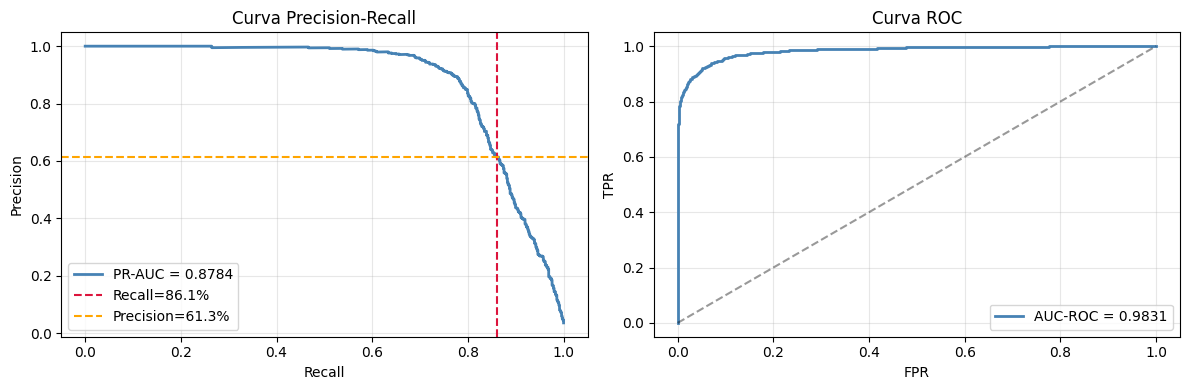

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
prec_c, rec_c, _ = precision_recall_curve(y_test, prob)
ax1.plot(rec_c, prec_c, color='steelblue', lw=2, label=f'PR-AUC = {pr_auc:.4f}')
ax1.axvline(recall, color='crimson', ls='--', label=f'Recall={recall:.1%}')
ax1.axhline(precision, color='orange', ls='--', label=f'Precision={precision:.1%}')
ax1.set_xlabel('Recall'); ax1.set_ylabel('Precision')
ax1.set_title('Curva Precision-Recall'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(fpr_c, tpr_c, color='steelblue', lw=2, label=f'AUC-ROC = {roc_auc:.4f}')
ax2.plot([0,1],[0,1],'k--', alpha=0.4)
ax2.set_xlabel('FPR'); ax2.set_ylabel('TPR')
ax2.set_title('Curva ROC'); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Falsos Negativos por Patrón

In [ ]:
def get_pattern(row):
    burst = row.get('numero_transacciones_ultima_hora',0)>5 and row.get('tiempo_desde_ultima_transaccion',9999)<300
    sil   = (row.get('importe_transaccion',0)<200 and row.get('dispositivo_reconocido',1)==1
             and row.get('cross_border',0)==0 and row.get('destino_alto_riesgo',0)==0)
    if burst and sil: return 'ambos'
    elif burst:        return 'burst'
    elif sil:          return 'silencioso'
    else:              return 'clasico'

fraud_mask = y_test == 1
X_fe_raw  = fe.transform(X_test_raw.copy())
fraud_fe  = X_fe_raw[fraud_mask].reset_index(drop=True)
fraud_raw = X_test_raw[fraud_mask].reset_index(drop=True)

patterns = []b
for i in range(len(fraud_raw)):
    row = dict(fraud_raw.iloc[i])
    row['cross_border'] = int(fraud_fe.iloc[i].get('cross_border',0)) if 'cross_border' in fraud_fe.columns else 0
    patterns.append(get_pattern(row))

fraud_df = pd.DataFrame({'prob':prob[fraud_mask],'pred':y_pred[fraud_mask],'pattern':patterns})
fraud_df['fn'] = (fraud_df['pred']==0).astype(int)
summary = fraud_df.groupby('pattern').agg(
    total=('fn','count'), fn=('fn','sum'), prob_media=('prob','mean')
).assign(pct_fn=lambda d: d['fn']/d['total']*100).sort_values('pct_fn',ascending=False)
print(summary.to_string())

            total  fn  prob_media     pct_fn
pattern                                     
silencioso      9   8    0.383594  88.888889
ambos           4   1    0.766941  25.000000
clasico       481  89    0.868821  18.503119
burst         213   0    0.994474   0.000000


### 3.1 Gráficas FN por patrón

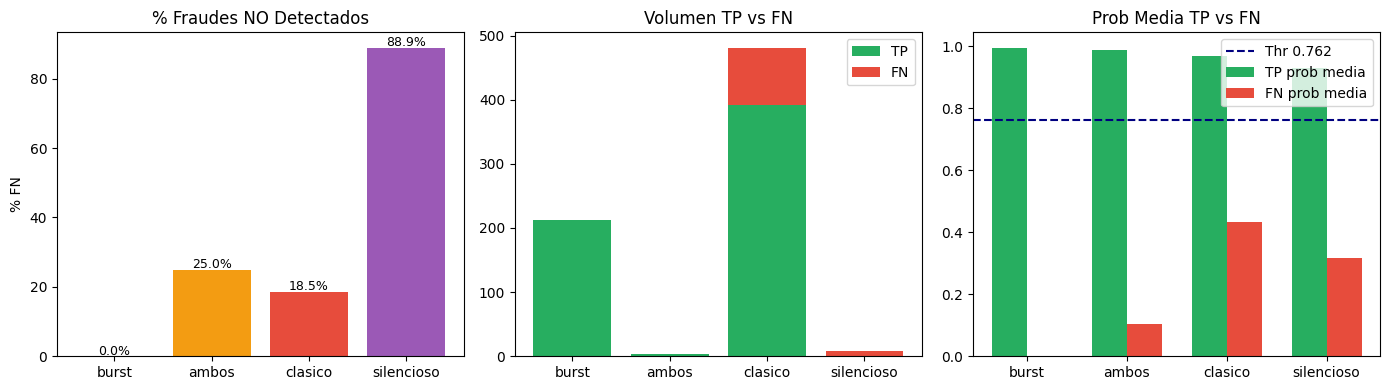

In [7]:
patterns_order = ['burst','ambos','clasico','silencioso']
colors = ['#2ecc71','#f39c12','#e74c3c','#9b59b6']
s = summary.reindex(patterns_order).dropna()
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].bar(s.index, s['pct_fn'], color=colors[:len(s)])
axes[0].set_title('% Fraudes NO Detectados')
axes[0].set_ylabel('% FN')
for i,(pat,row) in enumerate(s.iterrows()):
    axes[0].text(i, row['pct_fn']+0.5, f"{row['pct_fn']:.1f}%", ha='center', fontsize=9)
tp_counts = s['total'] - s['fn']
x = np.arange(len(s))
axes[1].bar(x, tp_counts.values, label='TP', color='#27ae60')
axes[1].bar(x, s['fn'].values, bottom=tp_counts.values, label='FN', color='#e74c3c')
axes[1].set_xticks(x); axes[1].set_xticklabels(s.index)
axes[1].set_title('Volumen TP vs FN'); axes[1].legend()
tp_p = fraud_df[fraud_df['fn']==0].groupby('pattern')['prob'].mean().reindex(patterns_order).dropna()
fn_p = fraud_df[fraud_df['fn']==1].groupby('pattern')['prob'].mean().reindex(patterns_order).dropna()
x2 = np.arange(len(s)); w=0.35
axes[2].bar(x2-w/2, tp_p.reindex(s.index).values, w, label='TP prob media', color='#27ae60')
axes[2].bar(x2+w/2, fn_p.reindex(s.index).fillna(0).values, w, label='FN prob media', color='#e74c3c')
axes[2].axhline(best_t, color='navy', ls='--', label=f'Thr {best_t:.3f}')
axes[2].set_xticks(x2); axes[2].set_xticklabels(s.index)
axes[2].set_title('Prob Media TP vs FN'); axes[2].legend()
plt.tight_layout(); plt.show()

## 4. Distribución de Probabilidades por Patrón

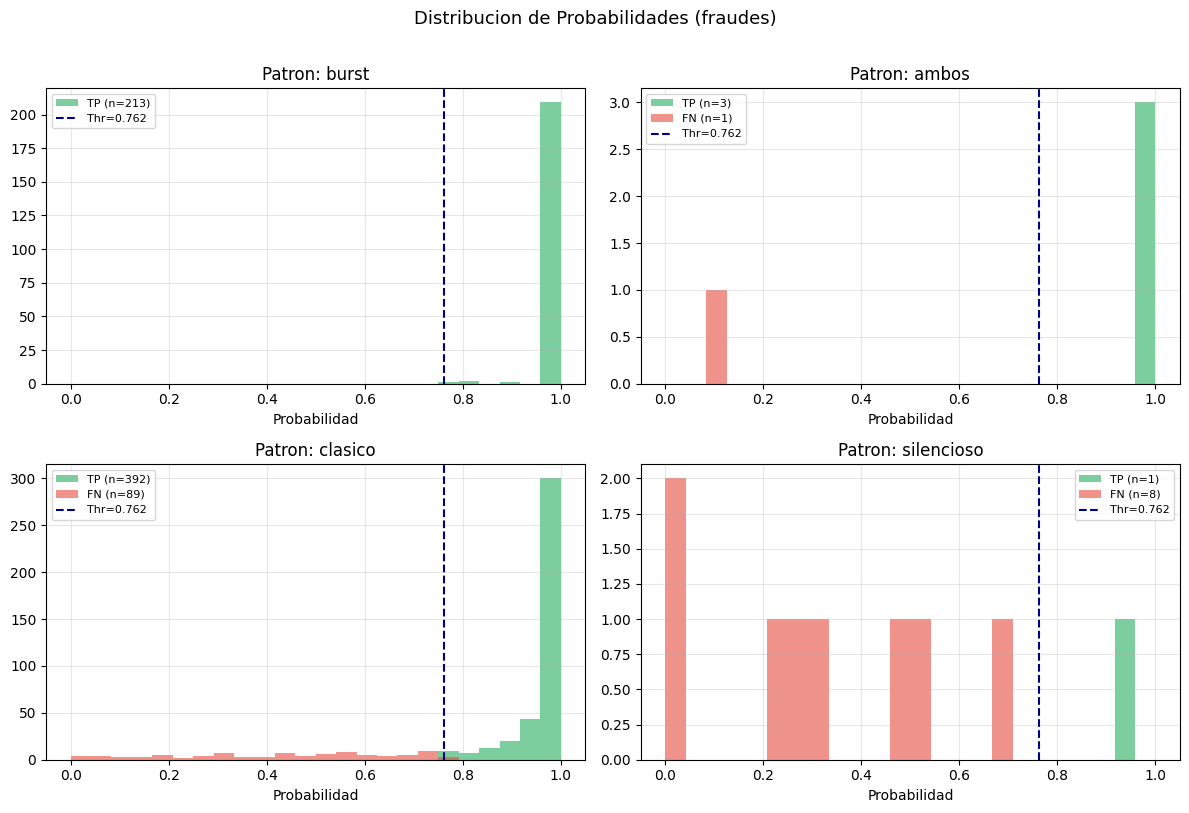

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i,pat in enumerate(patterns_order):
    ax = axes[i]
    tp_p = fraud_df[(fraud_df['pattern']==pat)&(fraud_df['fn']==0)]['prob']
    fn_p = fraud_df[(fraud_df['pattern']==pat)&(fraud_df['fn']==1)]['prob']
    bins = np.linspace(0,1,25)
    if len(tp_p): ax.hist(tp_p, bins=bins, alpha=0.6, color='#27ae60', label=f'TP (n={len(tp_p)})')
    if len(fn_p): ax.hist(fn_p, bins=bins, alpha=0.6, color='#e74c3c', label=f'FN (n={len(fn_p)})')
    ax.axvline(best_t, color='navy', ls='--', lw=1.5, label=f'Thr={best_t:.3f}')
    ax.set_title(f'Patron: {pat}'); ax.set_xlabel('Probabilidad')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle('Distribucion de Probabilidades (fraudes)', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

## 5. Perfil Silencioso — TP vs FN

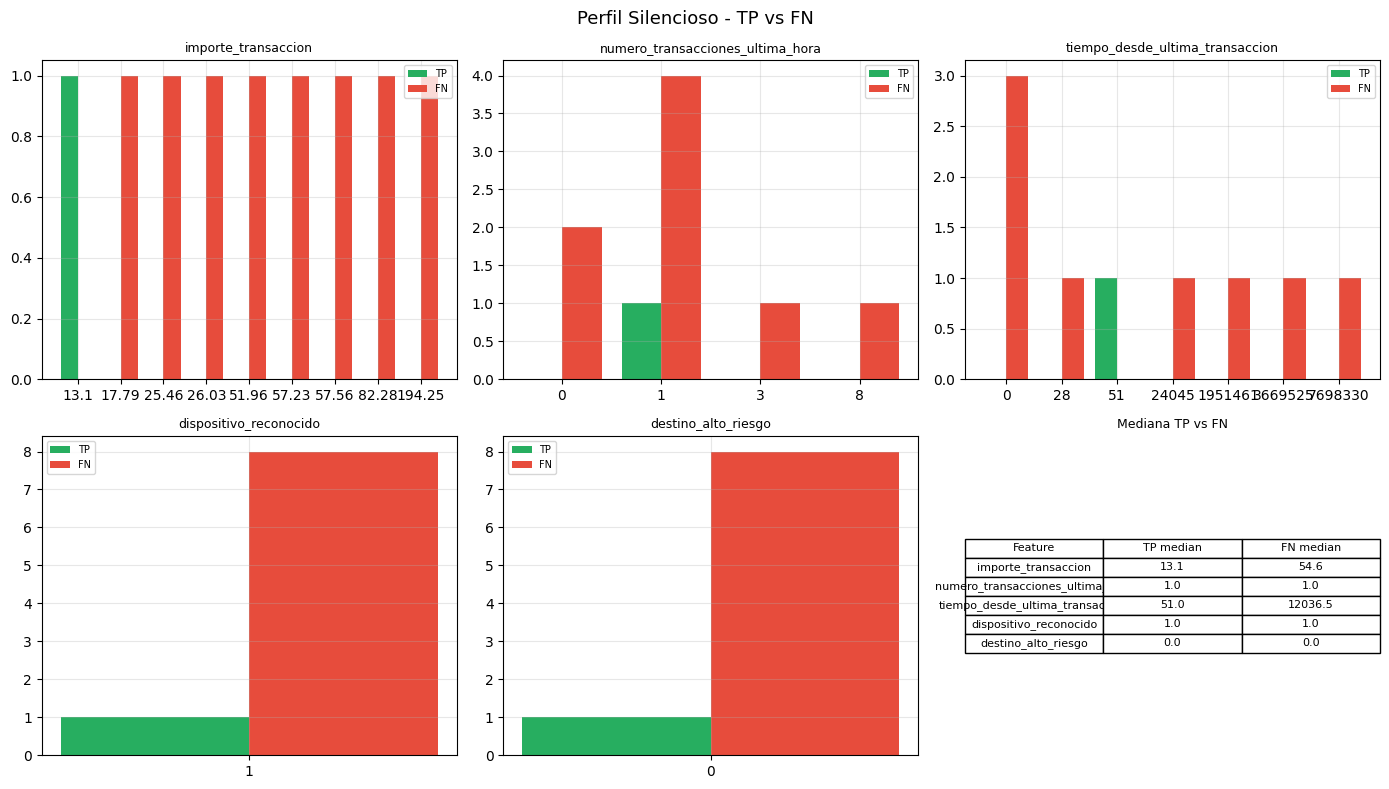

In [9]:
sil_tp_idx = fraud_df[(fraud_df['pattern']=='silencioso')&(fraud_df['fn']==0)].index
sil_fn_idx = fraud_df[(fraud_df['pattern']=='silencioso')&(fraud_df['fn']==1)].index
sil_tp_raw = fraud_raw.iloc[sil_tp_idx].copy()
sil_fn_raw = fraud_raw.iloc[sil_fn_idx].copy()
feats_cmp  = ['importe_transaccion','numero_transacciones_ultima_hora',
              'tiempo_desde_ultima_transaccion','dispositivo_reconocido','destino_alto_riesgo']
fig, axes = plt.subplots(2, 3, figsize=(14,8)); axes = axes.flatten()
for i,feat in enumerate(feats_cmp):
    ax = axes[i]
    if feat not in sil_tp_raw.columns: continue
    tv = sil_tp_raw[feat].dropna(); fv = sil_fn_raw[feat].dropna()
    if tv.nunique()>2:
        b = np.linspace(min(tv.min(),fv.min()),max(tv.max(),fv.max()),20)
        ax.hist(tv,bins=b,alpha=0.6,color='#27ae60',label=f'TP (n={len(tv)})')
        ax.hist(fv,bins=b,alpha=0.6,color='#e74c3c',label=f'FN (n={len(fv)})')
    else:
        cats=sorted(set(tv.unique())|set(fv.unique())); x=np.arange(len(cats))
        ax.bar(x-0.2,[tv.value_counts().get(cc,0) for cc in cats],0.4,color='#27ae60',label='TP')
        ax.bar(x+0.2,[fv.value_counts().get(cc,0) for cc in cats],0.4,color='#e74c3c',label='FN')
        ax.set_xticks(x); ax.set_xticklabels(cats)
    ax.set_title(feat,fontsize=9); ax.legend(fontsize=7); ax.grid(alpha=0.3)
ax=axes[5]; ax.axis('off')
rows_t=[[f,round(sil_tp_raw[f].median(),2),round(sil_fn_raw[f].median(),2)] for f in feats_cmp if f in sil_tp_raw.columns]
tbl=ax.table(cellText=rows_t,colLabels=['Feature','TP median','FN median'],cellLoc='center',loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(8); ax.set_title('Mediana TP vs FN',fontsize=9)
plt.suptitle('Perfil Silencioso - TP vs FN',fontsize=13); plt.tight_layout(); plt.show()

## 6. Distribución de Probabilidades en los FN

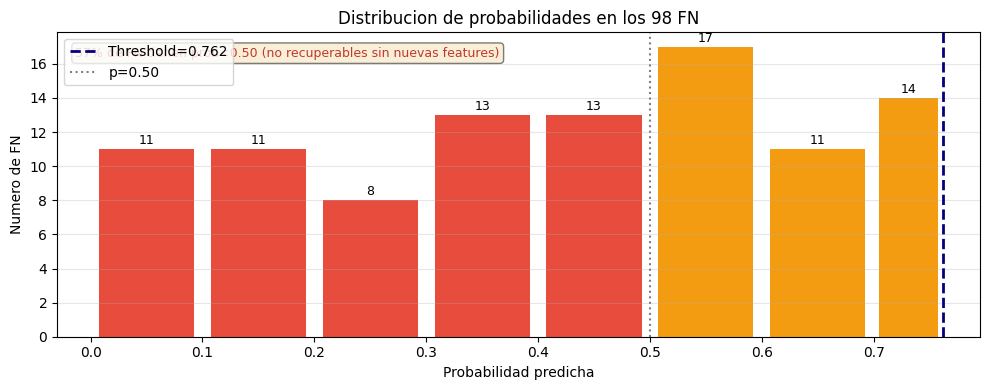

In [10]:
fn_probs = prob[(y_test==1)&(y_pred==0)]
fig, ax = plt.subplots(figsize=(10,4))
bins=[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,best_t]
counts,edges = np.histogram(fn_probs,bins=bins)
centers=(np.array(edges[:-1])+np.array(edges[1:]))/2
bars=ax.bar(centers,counts,width=np.diff(edges)*0.85,
            color=['#e74c3c' if cc<0.5 else '#f39c12' for cc in centers])
ax.axvline(best_t,color='navy',ls='--',lw=2,label=f'Threshold={best_t:.3f}')
ax.axvline(0.5,color='gray',ls=':',lw=1.5,label='p=0.50')
for bar,cnt in zip(bars,counts):
    if cnt>0: ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.3,str(cnt),ha='center',fontsize=9)
pct_below=(fn_probs<0.5).mean()
ax.text(0.02,0.92,f'{pct_below:.0%} de FN tienen prob<0.50 (no recuperables sin nuevas features)',
        transform=ax.transAxes,fontsize=9,color='#c0392b',
        bbox=dict(boxstyle='round',facecolor='wheat',alpha=0.5))
ax.set_xlabel('Probabilidad predicha'); ax.set_ylabel('Numero de FN')
ax.set_title(f'Distribucion de probabilidades en los {len(fn_probs)} FN')
ax.legend(); ax.grid(alpha=0.3,axis='y'); plt.tight_layout(); plt.show()

## 7. Perfil de los Falsos Positivos

FP: 384 | Legitimas OK: 18909


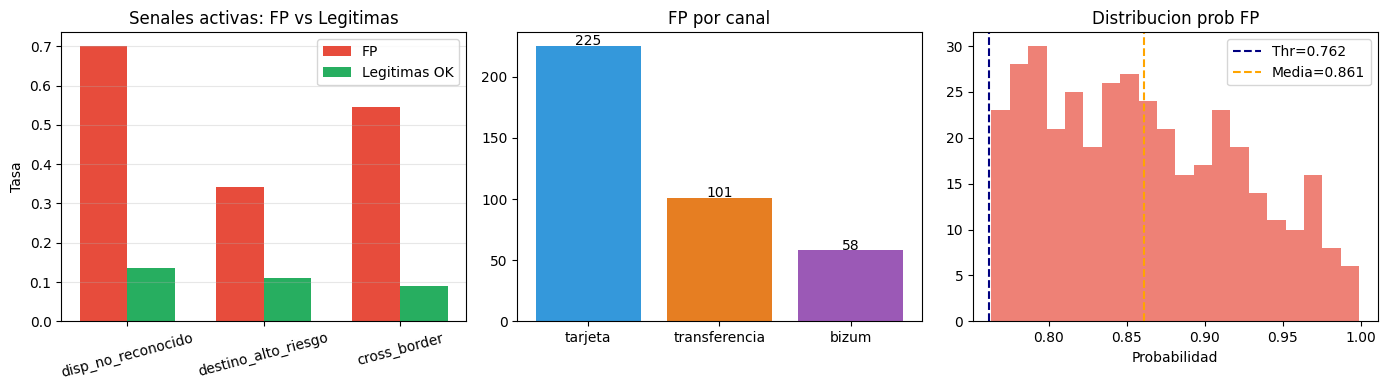

In [11]:
fp_mask  = (y_test==0)&(y_pred==1)
leg_mask = (y_test==0)&(y_pred==0)
fp_raw   = X_test_raw[fp_mask].reset_index(drop=True)
leg_raw  = X_test_raw[leg_mask].reset_index(drop=True)
fp_fe_raw  = X_fe_raw[fp_mask].reset_index(drop=True)
leg_fe_raw = X_fe_raw[leg_mask].reset_index(drop=True)
print(f'FP: {fp_mask.sum()} | Legitimas OK: {leg_mask.sum()}')
signals={'disp_no_reconocido':('dispositivo_reconocido',fp_raw,leg_raw,0),
          'destino_alto_riesgo':('destino_alto_riesgo',fp_raw,leg_raw,1),
          'cross_border':('cross_border',fp_fe_raw,leg_fe_raw,1)}
rates_fp,rates_leg,labs=[],[],[]
for nm,(col,src_fp,src_leg,val) in signals.items():
    if col in src_fp.columns:
        rates_fp.append((src_fp[col]==val).mean())
        rates_leg.append((src_leg[col]==val).mean())
        labs.append(nm)
fig,axes=plt.subplots(1,3,figsize=(14,4))
x=np.arange(len(labs)); w=0.35
axes[0].bar(x-w/2,rates_fp,w,color='#e74c3c',label='FP')
axes[0].bar(x+w/2,rates_leg,w,color='#27ae60',label='Legitimas OK')
axes[0].set_xticks(x); axes[0].set_xticklabels(labs,rotation=15)
axes[0].set_ylabel('Tasa'); axes[0].set_title('Senales activas: FP vs Legitimas')
axes[0].legend(); axes[0].grid(alpha=0.3,axis='y')
canal_fp=fp_raw['tipo_transaccion'].value_counts()
axes[1].bar(canal_fp.index,canal_fp.values,color=['#3498db','#e67e22','#9b59b6'])
axes[1].set_title('FP por canal')
for i2,v2 in enumerate(canal_fp.values): axes[1].text(i2,v2+0.5,str(v2),ha='center')
fp_probs=prob[fp_mask]
axes[2].hist(fp_probs,bins=20,color='#e74c3c',alpha=0.7)
axes[2].axvline(best_t,color='navy',ls='--',label=f'Thr={best_t:.3f}')
axes[2].axvline(fp_probs.mean(),color='orange',ls='--',label=f'Media={fp_probs.mean():.3f}')
axes[2].set_title('Distribucion prob FP'); axes[2].set_xlabel('Probabilidad'); axes[2].legend()
plt.tight_layout(); plt.show()

## 8. Heatmap Recall por Patrón × Canal

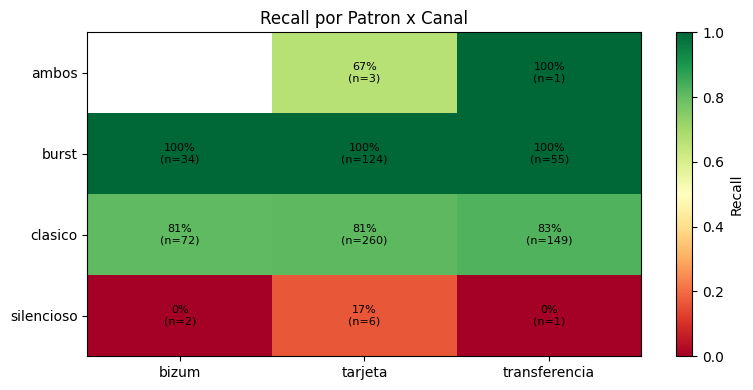

In [12]:
fraud_canal = X_test_raw[fraud_mask]['tipo_transaccion'].reset_index(drop=True).values
fraud_df['canal'] = fraud_canal
pivot = fraud_df.groupby(['pattern','canal']).apply(
    lambda d: (d['fn']==0).sum()/len(d) if len(d)>0 else float('nan')
).unstack(fill_value=float('nan'))
cnt_pivot = fraud_df.groupby(['pattern','canal']).size().unstack(fill_value=0)
fig,ax=plt.subplots(figsize=(8,4))
im=ax.imshow(pivot.values,cmap='RdYlGn',vmin=0,vmax=1,aspect='auto')
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index)
ax.set_title('Recall por Patron x Canal')
plt.colorbar(im,ax=ax,label='Recall')
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val=pivot.values[i,j]; n=int(cnt_pivot.iloc[i,j]) if i<cnt_pivot.shape[0] and j<cnt_pivot.shape[1] else 0
        if val==val: ax.text(j,i,f'{val:.0%}\n(n={n})',ha='center',va='center',fontsize=8)
plt.tight_layout(); plt.show()

## 9. Proxy `diff_tiempo_cliente`

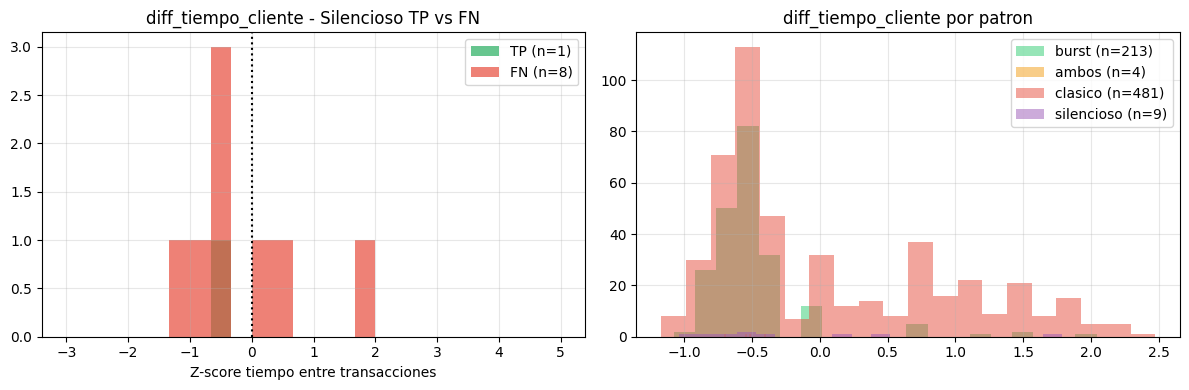

Media por patron:
pattern
ambos        -0.538
burst        -0.489
clasico       0.042
silencioso   -0.161
Name: diff_tiempo_cliente, dtype: float64


In [13]:
test_copy = test.copy().reset_index(drop=True)
test_copy['prob']=prob; test_copy['y_pred']=y_pred; test_copy['pattern']=None
for i,idx in enumerate(np.where(y_test==1)[0]):
    test_copy.loc[idx,'pattern']=fraud_df.iloc[i]['pattern']
cstats=(test_copy.groupby('id_cliente')['tiempo_desde_ultima_transaccion']
        .agg(['mean','std']).rename(columns={'mean':'t_mean','std':'t_std'}))
cstats['t_std']=cstats['t_std'].fillna(1).clip(lower=1)
test_copy=test_copy.join(cstats,on='id_cliente')
test_copy['diff_tiempo_cliente']=(test_copy['tiempo_desde_ultima_transaccion']-test_copy['t_mean'])/test_copy['t_std']
sil_all=test_copy[(test_copy['IS_FRAUD']==1)&(test_copy['pattern']=='silencioso')]
sil_tp2=sil_all[sil_all['y_pred']==1]; sil_fn2=sil_all[sil_all['y_pred']==0]
fig,axes=plt.subplots(1,2,figsize=(12,4))
bins=np.linspace(-3,5,25)
if len(sil_tp2): axes[0].hist(sil_tp2['diff_tiempo_cliente'],bins=bins,alpha=0.7,color='#27ae60',label=f'TP (n={len(sil_tp2)})')
if len(sil_fn2): axes[0].hist(sil_fn2['diff_tiempo_cliente'],bins=bins,alpha=0.7,color='#e74c3c',label=f'FN (n={len(sil_fn2)})')
axes[0].set_title('diff_tiempo_cliente - Silencioso TP vs FN')
axes[0].set_xlabel('Z-score tiempo entre transacciones')
axes[0].axvline(0,color='k',ls=':'); axes[0].legend(); axes[0].grid(alpha=0.3)
for pat,col in zip(patterns_order,['#2ecc71','#f39c12','#e74c3c','#9b59b6']):
    d=test_copy[(test_copy['IS_FRAUD']==1)&(test_copy['pattern']==pat)]['diff_tiempo_cliente'].dropna()
    if len(d): axes[1].hist(d,bins=20,alpha=0.5,color=col,label=f'{pat} (n={len(d)})')
axes[1].set_title('diff_tiempo_cliente por patron'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('Media por patron:')
print(test_copy[test_copy['IS_FRAUD']==1].groupby('pattern')['diff_tiempo_cliente'].mean().round(3))

## 10. Resumen Ejecutivo

In [14]:
print('='*60)
print('RESUMEN ANALISIS DE RESIDUOS - modelo_10_v3')
print('='*60)
print(f'  PR-AUC:{pr_auc:.4f}  AUC-ROC:{roc_auc:.4f}')
print(f'  Recall:{recall:.1%}  Precision:{precision:.1%}  F2:{f2:.4f}')
print(f'  TP={tp}  FP={fp}  FN={fn}  TN={tn}')
print()
print('FN por patron:')
for pat,row in summary.iterrows():
    print(f'  {pat:12s}: {int(row.fn)}/{int(row.total)} ({row.pct_fn:.1f}%) | prob_media={row.prob_media:.3f}')
pct_irr=(prob[(y_test==1)&(y_pred==0)]<0.5).mean()
print(f'  {pct_irr:.0%} de FN irrecuperables sin nuevas features')
print()
print('RECOMENDACIONES:')
print('  1. [PRIORITARIO] diff_tiempo_cliente')
print('  2. Ampliar silenciosos: 150->300-400 casos')
print('  3. Recalibracion isotonica (ECE=0.0616)')
print('  4. Umbral adaptativo Bizum')
print('='*60)

RESUMEN ANALISIS DE RESIDUOS - modelo_10_v3
  PR-AUC:0.8784  AUC-ROC:0.9831
  Recall:86.1%  Precision:61.3%  F2:0.7969
  TP=609  FP=384  FN=98  TN=18909

FN por patron:
  silencioso  : 8/9 (88.9%) | prob_media=0.384
  ambos       : 1/4 (25.0%) | prob_media=0.767
  clasico     : 89/481 (18.5%) | prob_media=0.869
  burst       : 0/213 (0.0%) | prob_media=0.994
  57% de FN irrecuperables sin nuevas features

RECOMENDACIONES:
  1. [PRIORITARIO] diff_tiempo_cliente
  2. Ampliar silenciosos: 150->300-400 casos
  3. Recalibracion isotonica (ECE=0.0616)
  4. Umbral adaptativo Bizum
